In [18]:
# from astropy.io import fits
# import pandas as pd
# import os

# with fits.open('/kaggle/input/datasets/maanav0114/harps-n-dataset/ADP.2023-12-04T15_16_53.464.fits') as data:
#     harps_df = pd.DataFrame(data[1].data)

# # Fix the big-endian to little-endian compiler issue
# harps_df.to_csv('/kaggle/working/temp.csv', index=False)
# del harps_df
# harps_df = pd.DataFrame(pd.read_csv('/kaggle/working/temp.csv'))
# os.remove('/kaggle/working/temp.csv')

# # Rename only the columns shared by both HARPS and HIRES
# # (instrument-specific columns like snr, drs_version, bisector_span, etc. are dropped)
# harps_df = harps_df.rename(columns={
#     'main_id_simbad': 'star_name',
#     'drs_bjd': 'bjd',
#     'drs_ccf_rvc': 'rv',
#     'drs_dvrms': 'rv_err',
#     'exptime': 'exposure_time',
# })

# # Keep only the unified schema
# shared_cols = ['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time']
# harps_df = harps_df[shared_cols]

# harps_df.describe()

In [19]:
import pandas as pd
import numpy as np 
import os



harps_df = pd.DataFrame(pd.read_csv('/kaggle/input/datasets/maanav0114/harps-n-dataset/HARPS_RVBank_ver02.csv'))
harps_df = harps_df.rename(columns={
    "target": "star_name",
    "BJD": 'bjd'
})

harps_df

,star_name,ra,dec,bjd,RV_mlc_nzp,e_RV_mlc_nzp,RV_drs_nzp,e_RV_drs_nzp,RV_mlc,e_RV_mlc,...,PROGID,PROGPI,AIRMASS,OBHAB,THAR_FP,DPR_TYPE,RHKp,dRHKp,vsinflag,metflag
0,HD160617,265.706979,-40.322215,2.454900e+06,2.054999,1.624905,100609.364065,1.322757,7.796334,1.443621,...,082.B-0610(A),UNKNOWN,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_objAB,STAR_SKY_F0V,0.000023,0.000016,1,0
1,HD160617,265.706979,-40.322215,2.454901e+06,5.281584,1.367853,100609.433016,1.203025,11.421773,1.066969,...,082.B-0610(A),UNKNOWN,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_objAB,STAR_SKY_F0V,0.000029,0.000015,1,0
2,HD160617,265.706979,-40.322215,2.454901e+06,2.492506,1.352994,100612.508432,1.199217,8.625994,1.047846,...,082.B-0610(A),UNKNOWN,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_objAB,STAR_SKY_F0V,0.000025,0.000011,1,0
3,HD160617,265.706979,-40.322215,2.454901e+06,5.699697,1.391036,100617.060115,1.218808,11.826615,1.096518,...,082.B-0610(A),UNKNOWN,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_objAB,STAR_SKY_F0V,0.000020,0.000013,1,0
4,HD160617,265.706979,-40.322215,2.454901e+06,1.497738,1.345356,100615.688940,1.202852,7.617891,1.037948,...,082.B-0610(A),UNKNOWN,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_objAB,STAR_SKY_F0V,0.000018,0.000012,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252610,WASP-98,58.428836,-34.328218,2.458449e+06,-27.251834,3.497063,-38277.643080,5.113226,-56.448632,3.272335,...,0102.C-0618,Esposito,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_wavesimult,STAR_WAVE_G2,0.000013,0.000002,0,0
252611,WASP-98,58.428836,-34.328218,2.458449e+06,-132.226414,3.677975,-38275.765752,5.011747,-161.403044,3.464998,...,0102.C-0618,Esposito,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_wavesimult,STAR_WAVE_G2,0.000128,0.000845,0,0
252612,WASP-98,58.428836,-34.328218,2.458449e+06,-66.068207,3.629083,-38286.871825,4.806497,-95.225620,3.413055,...,0102.C-0618,Esposito,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_wavesimult,STAR_WAVE_G2,0.000070,0.000006,0,0
252613,WASP-98,58.428836,-34.328218,2.458449e+06,5.548559,4.613560,-38303.524816,4.769089,-23.589065,4.445629,...,0102.C-0618,Esposito,-9999999,HARPS_ech_obs_all,HARPS_ech_obs_wavesimult,STAR_WAVE_G2,0.000310,0.001416,0,0


In [20]:
from pathlib import Path
import pandas as pd
import os

# Directory containing the raw HIRES .vels files
directory = Path("/kaggle/input/datasets/maanav0114/harps-n-dataset/keck_vels/keck_vels/")

# Initialize list to store rows
rows = []

# Process each .vels file
# File format: 7 columns per line — BJD, RV, RV_err, S-index, H-index, photon_count, exposure_time
# We only keep the 4 columns shared with HARPS (plus star_name)
for filename in os.listdir(directory):
    if filename.endswith('.vels'):
        star_name = filename.replace('_KECK.vels', '')
        filepath = directory / filename

        with open(filepath, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue

                values = line.split()
                if len(values) != 7:
                    continue  # Skip malformed lines

                row = {
                    'star_name': star_name,
                    'bjd': float(values[0]),
                    'RV_mlc_nzp': float(values[1]),
                    'e_RV_mlc_nzp': float(values[2]),
                    'RHKp': float(values[3]),
                    'Halpha': float(values[4]),
                    # values[3] = S-index (HIRES-only, skip)
                    # values[4] = H-index (HIRES-only, skip)
                    # values[5] = photon_count (HIRES-only, skip)
                    'EXPTIME': int(values[6])
                }
                rows.append(row)

hires_df = pd.DataFrame(rows)
hires_df

,star_name,bjd,RV_mlc_nzp,e_RV_mlc_nzp,RHKp,Halpha,EXPTIME
0,HD204587,2.450366e+06,2.28,1.38,0.7319,-1.00000,600
1,HD204587,2.450366e+06,2.26,1.35,0.7536,-1.00000,600
2,HD204587,2.450605e+06,0.21,1.34,0.7556,-1.00000,600
3,HD204587,2.450666e+06,-8.34,1.40,0.8488,-1.00000,600
4,HD204587,2.450714e+06,-0.47,1.50,0.8751,-1.00000,450
...,...,...,...,...,...,...,...
75057,HD104860,2.455197e+06,2.54,6.65,0.3621,0.03632,46
75058,HD104860,2.455703e+06,-13.56,5.30,0.3147,0.03643,55
75059,HD104860,2.456019e+06,16.48,5.69,0.3201,0.03671,96
75060,HD104860,2.456484e+06,0.00,6.08,0.2887,0.03581,92


In [21]:
harps_stars = []
for name in list(set(list(harps_df['star_name']))):
    name = name.split(" ")
    name = "".join(name)
    name = name.lower()

    harps_stars.append(name)

harps_stars[:10]

['hd58972',
 'gj4005',
 'hd215906',
 'hd61935',
 'hd147048',
 'tyc8963-1543-1',
 'gj3799',
 'tyc8502-1226-1',
 'hd163652',
 'hd111232']

In [22]:
# Combine HARPS and HIRES datasets into one unified dataset
# Schema: star_name, bjd, rv, rv_err, exposure_time (shared by both instruments)
# No instrument-specific columns — model will be instrument-agnostic

shared_cols = ['star_name', 'bjd', 'RV_mlc_nzp', 'e_RV_mlc_nzp', 'EXPTIME', 'RHKp', 'Halpha']

# HARPS subset
observations = harps_df[shared_cols].copy()

# Filter out HIRES stars already in HARPS dataset (avoid duplicates)
cleaned_names = hires_df['star_name'].str.lower().str.replace(' ', '', regex=False)
harps_stars_set = set(harps_stars)
mask = ~cleaned_names.isin(harps_stars_set)

# HIRES subset (only stars not already in HARPS)
hires_subset = hires_df[mask].copy()

# Combine both datasets
observations = pd.concat([observations, hires_subset], ignore_index=True)

# Drop rows missing essential measurements
observations = observations.dropna()
observations = observations.rename(columns = {
    'RV_mlc_nzp': 'rv',
    'e_RV_mlc_nzp': 'rv_err',
    'EXPTIME': 'exposure_time',
})

observations

,star_name,bjd,rv,rv_err,exposure_time,RHKp,Halpha
0,HD160617,2.454900e+06,2.054999,1.624905,2700,0.000023,0.411629
1,HD160617,2.454901e+06,5.281584,1.367853,1800,0.000029,0.411177
2,HD160617,2.454901e+06,2.492506,1.352994,1800,0.000025,0.411119
3,HD160617,2.454901e+06,5.699697,1.391036,1800,0.000020,0.410472
4,HD160617,2.454901e+06,1.497738,1.345356,1800,0.000018,0.410467
...,...,...,...,...,...,...,...
313601,HD104860,2.455197e+06,2.540000,6.650000,46,0.362100,0.036320
313602,HD104860,2.455703e+06,-13.560000,5.300000,55,0.314700,0.036430
313603,HD104860,2.456019e+06,16.480000,5.690000,96,0.320100,0.036710
313604,HD104860,2.456484e+06,0.000000,6.080000,92,0.288700,0.035810


In [23]:
for column in observations.columns:
    observations = observations[observations[column] != -9999999.0] # Equivalent to NaN

In [24]:
# Label each observation: 1 if the star has a confirmed RV-discovered exoplanet, 0 otherwise.
# Two fixes vs prior version:
#   (1) Resolve star_name -> SIMBAD main_id + aliases (HIP <-> HD <-> GJ <-> TYC cross-references)
#   (2) Restrict NEA query to discoverymethod='Radial Velocity' + default_flag=1, so transit-only
#       hosts (e.g. WASP-98) do not pollute the positive class.
# Caveat: 'discoverymethod = Radial Velocity' means the star was used to first detect at least
# one planet via RV, NOT that the star today necessarily has a detectable RV signal. Some hosts
# have only face-on / very-low-amplitude RV-detected planets, so they remain hard positives.
# We pin to pl_pubdate < '2025-06-01' so a notebook re-run gives the same labels until the
# cutoff is deliberately bumped and the labels are regenerated.

import requests, io, re, sys, subprocess
import pandas as pd

# --- 0. Ensure astroquery is available (Kaggle may not have it pre-installed) ---
try:
    from astroquery.simbad import Simbad
except ImportError:
    print('Installing astroquery (one-time)...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'astroquery'])
    from astroquery.simbad import Simbad

NEA_TAP    = 'https://exoplanetarchive.ipac.caltech.edu/TAP/sync'
LABEL_CUTOFF = '2025-06-01'   # bump on each deliberate label regen

# --- 1. Name normalizers (applied symmetrically to NEA hosts AND our star_name values) ---
def norm(name):
    '''Lowercase, strip whitespace, keep only word chars (A-Za-z0-9_).
       Note: the underscore IS a word char, so it is intentionally preserved.
       Stripped chars: spaces, hyphens, dots, quotes, asterisks, etc.'''
    if pd.isna(name): return ''
    s = str(name).lower()
    s = re.sub(r'\s+', '', s)
    s = re.sub(r'[^\w]', '', s)   # keep A-Za-z0-9_; drop punctuation
    return s

def strip_simbad_prefix(name):
    '''Strip common SIMBAD object-type prefixes (e.g. '* tau Cet', 'V* RR Lyr', 'EM* ...').'''
    if pd.isna(name): return ''
    s = str(name).strip()
    s = re.sub(r'^\*\s+', '', s)                  # '* tau Cet' -> 'tau Cet'
    s = re.sub(r'^[A-Z]+[a-z]*\*\s+', '', s)      # 'V* RR Lyr' -> 'RR Lyr'
    return s.strip()

# --- 2. NEA TAP: RV-discovered planet hosts, canonical parameters, pinned cutoff ---
nea_query_rv = f'''
SELECT DISTINCT hostname
FROM ps
WHERE default_flag = 1
  AND discoverymethod = 'Radial Velocity'
  AND pl_pubdate < '{LABEL_CUTOFF}'
'''
print('[NEA] Querying TAP for RV-discovered planet hosts (default_flag=1, cutoff=' + LABEL_CUTOFF + ')...', flush=True)
try:
    nea_rv_resp = requests.get(NEA_TAP, params={'query': nea_query_rv, 'lang': 'ADQL', 'format': 'csv'}, timeout=120)
    nea_rv_resp.raise_for_status()
    nea_rv_df = pd.read_csv(io.StringIO(nea_rv_resp.text))
except Exception as _nea_err:
    raise RuntimeError(
        f'[NEA] TAP query failed. Check network, ADQL syntax, and that LABEL_CUTOFF={LABEL_CUTOFF} is valid.\n'
        f'Raw error: {_nea_err}') from _nea_err
nea_rv_hosts_norm = {norm(strip_simbad_prefix(h)) for h in nea_rv_df['hostname']}
print(f'  -> {len(nea_rv_hosts_norm)} unique NEA hosts with at least one RV-discovered planet')

# --- 3. SIMBAD alias resolution for every distinct star_name (batched) ---
unique_star_names = observations['star_name'].dropna().drop_duplicates().tolist()
print(f'[SIMBAD] Resolving {len(unique_star_names)} unique star_name values...', flush=True)
Simbad.add_votable_fields('ids')
Simbad.TIMEOUT = 120
Simbad.ROW_LIMIT = 10000
resolved = {}              # raw_name -> {'main_id': str|None, 'aliases': set(str)}
BATCH = 400
for start in range(0, len(unique_star_names), BATCH):
    chunk = unique_star_names[start:start+BATCH]
    try:
        r = Simbad.query_objects(chunk)
        if r is not None and len(r) > 0:
            for raw, main_id, ids_val in zip(r['user_specified_id'], r['main_id'], r['ids']):
                clean = str(raw).strip()
                aliases = set()
                if main_id is not None and str(main_id).strip():
                    aliases.add(str(main_id).strip())
                if ids_val is not None and str(ids_val).strip():
                    for tok in str(ids_val).split('|'):
                        tok = tok.strip()
                        if tok:
                            aliases.add(tok)
                aliases.add(clean)            # always include the raw form as final fallback
                resolved[clean] = {
                    'main_id': (str(main_id).strip() if main_id is not None and str(main_id).strip() else None),
                    'aliases': aliases,
                }
    except Exception as e:
        print(f'[SIMBAD] batch {start}-{start+BATCH} failed: {e}', flush=True)
    for n in chunk:
        resolved.setdefault(n, {'main_id': None, 'aliases': {n}})
    if (start // BATCH) % 5 == 0:
        print(f'  ... {min(start + BATCH, len(unique_star_names))}/{len(unique_star_names)} names processed', flush=True)

unresolved = sum(1 for v in resolved.values() if v['main_id'] is None)
print(f'  -> {unresolved}/{len(unique_star_names)} SIMBAD lookups returned no main_id (will fall back to direct match)')

# --- 4. has_exoplanets: positive iff ANY alias (or raw form) normalizes into nea_rv_hosts_norm ---
def is_rv_host(raw_name):
    info = resolved.get(raw_name)
    candidates = set()
    if info is not None:
        candidates |= info['aliases']
    candidates.add(raw_name)
    for c in candidates:
        if norm(strip_simbad_prefix(c)) in nea_rv_hosts_norm:
            return True
    return False

print('[LABEL] Assigning has_exoplanets labels...', flush=True)
star_labels = {n: 1 if is_rv_host(n) else 0 for n in unique_star_names}
n_pos_stars = sum(1 for v in star_labels.values() if v == 1)
n_neg_stars = len(star_labels) - n_pos_stars
print(f'  Positives: {n_pos_stars}    Negatives: {n_neg_stars}')

for col in ('has_exoplanets', 'normalized_name'):
    if col in observations.columns:
        observations = observations.drop(columns=[col])
label_df = pd.DataFrame(list(star_labels.items()), columns=['star_name', 'has_exoplanets'])
observations = observations.merge(label_df, on='star_name', how='left')
if 'has_exoplanets' not in observations.columns:
    raise RuntimeError(
        'Cell 6: merge completed but has_exoplanets column is missing!\n'
        'observations columns: ' + str(list(observations.columns)) + '\n'
        'label_df columns:    ' + str(list(label_df.columns)) + '\n'
        'This usually means a dtype mismatch between observations[star_name] '
        '(dtype=' + str(observations['star_name'].dtype) + ') and label_df[star_name] '
        '(dtype=' + str(label_df['star_name'].dtype) + '). '
        'Try: observations["star_name"] = observations["star_name"].astype(str)')

# --- 5. Final summary ---
n_uniq = observations['star_name'].nunique()
n_pos = observations.loc[observations['has_exoplanets'] == 1, 'star_name'].nunique()
n_neg = observations.loc[observations['has_exoplanets'] == 0, 'star_name'].nunique()
print('\nFinal label distribution (RV-discovered hosts, after SIMBAD alias resolution):')
print(f'  Total unique stars : {n_uniq}')
print(f'  Positives (has_exoplanets=1): {n_pos}')
print(f'  Negatives (has_exoplanets=0): {n_neg}')
print(f'  Class ratio 1 : {n_neg / max(1, n_pos):.2f}')

pos_sample = observations.loc[observations['has_exoplanets'] == 1, 'star_name'].drop_duplicates().head(5).tolist()
neg_sample = observations.loc[observations['has_exoplanets'] == 0, 'star_name'].drop_duplicates().head(5).tolist()
print(f'\nSample positives: {pos_sample}')
print(f'Sample negatives: {neg_sample}')


[NEA] Querying TAP for RV-discovered planet hosts (default_flag=1, cutoff=2025-06-01)...
  -> 783 unique NEA hosts with at least one RV-discovered planet
[SIMBAD] Resolving 5923 unique star_name values...
  ... 400/5923 names processed
  ... 2400/5923 names processed
  ... 4400/5923 names processed
  -> 130/5923 SIMBAD lookups returned no main_id (will fall back to direct match)
[LABEL] Assigning has_exoplanets labels...
  Positives: 527    Negatives: 5396

Final label distribution (RV-discovered hosts, after SIMBAD alias resolution):
  Total unique stars : 5923
  Positives (has_exoplanets=1): 527
  Negatives (has_exoplanets=0): 5396
  Class ratio 1 : 10.24

Sample positives: ['HIP49067', 'HD216435', 'BD-043588', 'GJ3138', 'GJ876']
Sample negatives: ['HD160617', 'HD290038', 'TYC1866-2486-1', 'GJ452', 'GJ45']


In [25]:
# Removing all stars with less than 20 observations

counts = observations.groupby('star_name')['star_name'].transform('size')
observations = observations[counts >= 20]

# Per-star mean subtraction for RV

observations['rv_mean'] = observations.groupby('star_name')['rv'].transform('mean')
observations['rv_centered'] = observations['rv'] - observations['rv_mean']

# Verification

for star in observations['star_name'].unique()[:3]:
    star_data = observations[observations['star_name'] == star]
    print(f"{star}: original mean = {star_data['rv'].mean():.2f}, centered mean = {star_data['rv_centered'].mean():.6f}")

HD290038: original mean = 0.26, centered mean = 0.000000
K2-314: original mean = -0.60, centered mean = -0.000000
HD96544: original mean = 1.23, centered mean = 0.000000


In [26]:
observations = observations.dropna(subset=['rv_centered'])

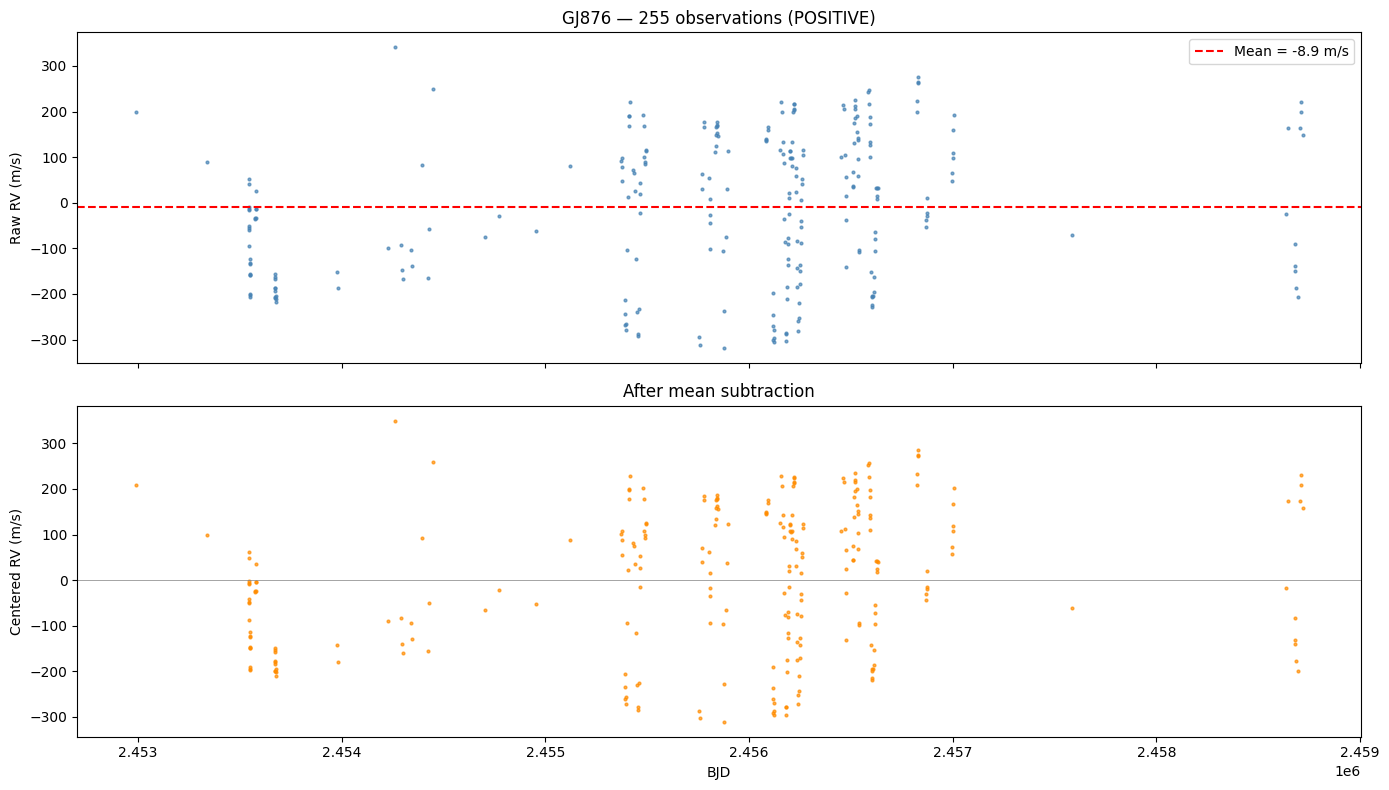


Positive example: GJ876 (255 obs, mean=-8.9 m/s)
Negative example: HD290038 (28 obs, mean=0.3 m/s)


In [27]:
import matplotlib.pyplot as plt

# Guard: did cell 6 (labeling) run?
if 'has_exoplanets' not in observations.columns:
    raise RuntimeError(
        'has_exoplanets column is missing from observations. '
        'Did cell 6 (the labeling cell) run successfully? '
        'Go back and re-run cell 6, then re-run this cell.')

observations['rv_mean'] = observations.groupby('star_name')['rv'].transform('mean')
observations['rv_centered'] = observations['rv'] - observations['rv_mean']

positive_stars = observations[observations['has_exoplanets'] == 1]['star_name'].unique()
if len(positive_stars) == 0:
    raise RuntimeError('No positive stars found. Did cell 6 run successfully?')
sample_star = positive_stars[min(3, len(positive_stars) - 1)]  # guard against <4 positives
star_data = observations[observations['star_name'] == sample_star].sort_values('bjd')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.scatter(star_data['bjd'], star_data['rv'], s=4, alpha=0.7, c='steelblue')
ax1.axhline(y=star_data['rv_mean'].iloc[0], color='red', linestyle='--', label=f"Mean = {star_data['rv_mean'].iloc[0]:.1f} m/s")
ax1.set_ylabel('Raw RV (m/s)')
ax1.set_title(f'{sample_star} — {len(star_data)} observations (POSITIVE)')
ax1.legend()

ax2.scatter(star_data['bjd'], star_data['rv_centered'], s=4, alpha=0.7, c='darkorange')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('BJD')
ax2.set_ylabel('Centered RV (m/s)')
ax2.set_title('After mean subtraction')

plt.tight_layout()
plt.show()

negative_stars = observations[observations['has_exoplanets'] == 0]['star_name'].unique()
neg_star = negative_stars[0]
neg_data = observations[observations['star_name'] == neg_star].sort_values('bjd')
print(f'\nPositive example: {sample_star} ({len(star_data)} obs, mean={star_data["rv_mean"].iloc[0]:.1f} m/s)')
print(f'Negative example: {neg_star} ({len(neg_data)} obs, mean={neg_data["rv_mean"].iloc[0]:.1f} m/s)')


In [28]:
# Quality-flag filtering: remove known-bad observations
# Only filters based on shared columns (no instrument-specific checks)

n_before = len(observations)

# Filter 1: zero exposure time (no light collected — observation is invalid)
if 'exposure_time' in observations.columns:
    bad_exptime = observations['exposure_time'] == 0.0
    print(f'Zero exposure_time observations: {bad_exptime.sum()}')
    observations = observations[~bad_exptime]

# Filter 2: extremely high RV error (likely failed measurement)
rv_err_cutoff = observations['rv_err'].quantile(0.999)
bad_rv_err = observations['rv_err'] > rv_err_cutoff
print(f'Extremely high RV error (>{rv_err_cutoff:.2f} m/s): {bad_rv_err.sum()}')
observations = observations[~bad_rv_err]

# Filter 3: zero or negative rv_err (invalid uncertainty)
bad_rv_err_zero = observations['rv_err'] <= 0
print(f'Zero or negative RV error: {bad_rv_err_zero.sum()}')
observations = observations[~bad_rv_err_zero]

n_after = len(observations)
print(f'\nObservations: {n_before} → {n_after} (removed {n_before - n_after})')
print(f'Stars remaining: {observations["star_name"].nunique()}')
print(f'Positive stars: {observations[observations["has_exoplanets"] == 1]["star_name"].nunique()}')

Zero exposure_time observations: 1683
Extremely high RV error (>74.68 m/s): 236
Zero or negative RV error: 0

Observations: 237486 → 235567 (removed 1919)
Stars remaining: 2187
Positive stars: 424


In [29]:
# Saving dataframe to pickle file

observations = observations.drop(columns=['rv_mean'], errors='ignore')

observations.to_pickle('/kaggle/working/observations.pkl')
print(f'{observations[observations["has_exoplanets"] == 1]["star_name"].nunique()} stars with detectable planets.')
print(f'Dataset shape: {observations.shape}')
print(f'Columns: {list(observations.columns)}')

424 stars with detectable planets.
Dataset shape: (235567, 9)
Columns: ['star_name', 'bjd', 'rv', 'rv_err', 'exposure_time', 'RHKp', 'Halpha', 'has_exoplanets', 'rv_centered']


In [30]:
# Validation: sample 20 stars from each class and cross-check against NEA ground truth (ANY planet).
# Even though we now label only RV-discovered hosts, we can use this cell to quantify
# (a) how many of our POSITIVES are real planet hosts (expected: ~100%, modulo aliases),
# (b) how many NEGATIVES are actually known planet hosts (false negatives — limit on label noise).

import random
random.seed(42)

# Ground truth: ANY confirmed planet (default_flag=1) at the SAME pinned cutoff as cell 6.
gt_query = f'''
SELECT DISTINCT hostname, discoverymethod
FROM ps
WHERE default_flag = 1
  AND pl_pubdate < '{LABEL_CUTOFF}'
'''
print('[VAL] Querying NEA ground truth (any confirmed planet)...', flush=True)
gt_resp = requests.get(NEA_TAP, params={'query': gt_query, 'lang': 'ADQL', 'format': 'csv'}, timeout=120)
gt_resp.raise_for_status()
gt_df = pd.read_csv(io.StringIO(gt_resp.text))
# Precompute normalized hostname column once so per-star lookups are O(1) instead of O(N_gt) lambda.
gt_df['norm_host'] = [norm(strip_simbad_prefix(h)) for h in gt_df['hostname']]
gt_hosts_norm = set(gt_df['norm_host'])
print(f'  -> {len(gt_hosts_norm)} unique hosts in NEA ground truth')
# Build one dict mapping normalized hostname -> sorted set of discovery methods (provenance).
_gt_methods_by_host = {}
for nh, m in zip(gt_df['norm_host'], gt_df['discoverymethod']):
    _gt_methods_by_host.setdefault(nh, set()).add(str(m))

def is_known_host_any_method(raw_name):
    info = resolved.get(raw_name)
    candidates = {raw_name}
    if info is not None:
        candidates |= info['aliases']
    for c in candidates:
        if norm(strip_simbad_prefix(c)) in gt_hosts_norm:
            return True
    return False

def discovery_methods(raw_name):
    info = resolved.get(raw_name)
    candidates = {raw_name}
    if info is not None:
        candidates |= info['aliases']
    methods = set()
    for c in candidates:
        nh = norm(strip_simbad_prefix(c))
        if nh in _gt_methods_by_host:
            methods |= _gt_methods_by_host[nh]
    return sorted(methods)

pos_stars = observations.loc[observations['has_exoplanets'] == 1, 'star_name'].drop_duplicates().tolist()
neg_stars = observations.loc[observations['has_exoplanets'] == 0, 'star_name'].drop_duplicates().tolist()
pos_sample = random.sample(pos_stars, min(20, len(pos_stars)))
neg_sample = random.sample(neg_stars, min(20, len(neg_stars)))

print(f'\n{"="*78}')
print('VALIDATION: positives we labeled  (label=1) vs NEA ground truth')
print('='*78)
pos_agree, pos_disagree, pos_disagree_list = 0, 0, []
for s in pos_sample:
    gt_has = is_known_host_any_method(s)
    if gt_has: pos_agree += 1
    else:
        pos_disagree += 1
        pos_disagree_list.append(s)
    methods = ','.join(discovery_methods(s)) or '-'
    print(f'  {s:<24}  our=POS  gt={'PLANET' if gt_has else 'NONE ':<6}  methods={methods}')

print(f'\n{"="*78}')
print('VALIDATION: negatives we labeled  (label=0) vs NEA ground truth')
print('='*78)
neg_agree, neg_disagree, neg_disagree_list = 0, 0, []
for s in neg_sample:
    gt_has = is_known_host_any_method(s)
    if not gt_has: neg_agree += 1
    else:
        neg_disagree += 1
        neg_disagree_list.append(s)
    methods = ','.join(discovery_methods(s)) or '-'
    print(f'  {s:<24}  our=NEG  gt={'PLANET' if gt_has else 'NONE ':<6}  methods={methods}')

print(f'\n{"="*78}')
print(f'VALIDATION SUMMARY  (sample: {len(pos_sample)} positives + {len(neg_sample)} negatives)')
print('='*78)
print(f'  Positive-class agreement (label=1, gt has planet):     {pos_agree}/{len(pos_sample)}')
print(f'  Negative-class agreement (label=0, gt has no planet):  {neg_agree}/{len(neg_sample)}')
total_correct = pos_agree + neg_agree
total_studied = len(pos_sample) + len(neg_sample)
print(f'  Overall agreement: {total_correct}/{total_studied} = {100 * total_correct / total_studied:.1f}%')
if pos_disagree_list:
    print(f'  Positives w/ no NEA planet (likely SIMBAD resolution miss): {pos_disagree_list}')
if neg_disagree_list:
    print(f'  Negatives w/ detected planet (transit-only hosts or alias miss): {neg_disagree_list}')

print('\nInterpretation:')
print('  - High POS-class agreement => SIMBAD alias resolution is working')
print('  - Low NEG-class agreement => either (a) transit-only hosts polluting, or')
print('                              (b) negative class contains transit-discovered hosts we excluded')
print('  - Positives w/ no NEA planet => SIMBAD might not have resolved the name; investigate')


[VAL] Querying NEA ground truth (any confirmed planet)...
  -> 4332 unique hosts in NEA ground truth

VALIDATION: positives we labeled  (label=1) vs NEA ground truth
  HD40979                   our=POS  gt=PLANET  methods=Radial Velocity
  HD204961                  our=POS  gt=PLANET  methods=Radial Velocity
  HD97037                   our=POS  gt=PLANET  methods=Radial Velocity
  HD190007                  our=POS  gt=PLANET  methods=Radial Velocity
  HD108341                  our=POS  gt=PLANET  methods=Radial Velocity
  HD48265                   our=POS  gt=PLANET  methods=Radial Velocity
  HD94771                   our=POS  gt=PLANET  methods=Radial Velocity
  GJ1061                    our=POS  gt=PLANET  methods=Radial Velocity
  HD213472                  our=POS  gt=PLANET  methods=Radial Velocity
  HD128356                  our=POS  gt=PLANET  methods=Radial Velocity
  HD192310                  our=POS  gt=PLANET  methods=Radial Velocity
  HD149026                  our=POS  gt=PL